# Tutorial 03 — Silicon: disentanglement and band interpolation

The waw-native reimagining of Wannier90 tutorial 3 — the first **disentanglement** example. We build **8** $sp^3$ atom-centred MLWFs for silicon (4 per Si atom). These do *not* come from an isolated set of bands: they span the 4 valence bands **plus** 4 low conduction bands, which are entangled with the rest of the conduction manifold. Disentanglement extracts an optimally-connected 8-dimensional subspace using an **outer window** (states allowed to mix) and a **frozen window** (states kept exactly — here the whole valence).

Same waw-native pipeline as tutorial 01, with `pw2wannier90` SCDM in `erfc` mode (a smooth energy weighting for entangled bands) and waw's disentanglement driven by the two energy windows.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Diamond-cubic Si, $a = 5.43$ Å, `ecutwfc = 40` Ry (Si has no semicore — a clean 4-valence pseudo). The NSCF computes 16 bands so the conduction states entering the outer window are available. SCDM `erfc` with $\mu = 12$ eV, $\sigma = 4$ eV weights the projection toward the valence + lower-conduction manifold.

In [2]:
from ase.build import bulk
atoms = bulk('Si', 'diamond', a=5.43)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'si'

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=16, num_wann=8,
    scdm_entanglement='erfc', scdm_mu=12.0, scdm_sigma=4.0,
    pseudopotentials={'Si': 'Si.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/si/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (64, 8, 16, 16), 'amn': (64, 16, 8), 'eig': (64, 16)}


### 2. Disentangle + Wannierise
The **frozen window** ends at 6.4 eV (just above the valence-band maximum, so all 4 valence bands are kept exactly); the **outer window** extends to 17 eV, letting the 4 extra Wannier states be built from an optimal mix of the low conduction bands.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=8, outer_window=(-1e3, 17.0), frozen_window=(-1e3, 6.4),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
)
omega_I = result.dis.omega_i * BOHR_TO_ANG**2
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_I     = {omega_I:.4f} Ang^2   (Wannier90 tutorial 3: 11.85)')
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial 3: 14.50)')
print('per-WF spreads (Ang^2):', spreads.round(3))

Omega_I     = 11.9087 Ang^2   (Wannier90 tutorial 3: 11.85)
Omega_total = 14.5471 Ang^2   (Wannier90 tutorial 3: 14.50)
per-WF spreads (Ang^2): [1.818 1.818 1.818 1.818 1.818 1.818 1.818 1.818]


$\Omega_I$ — the gauge-invariant part fixed by the chosen subspace — matches Wannier90's value, confirming waw found the same optimally-connected subspace. The 8 MLWFs are equivalent ($sp^3$ hybrids, 4 per atom).

### 3. Interpolated band structure
The 8-band Wannier model interpolates the silicon bands onto any k-path. Inside the **frozen window** (shaded) the interpolation reproduces the DFT valence bands essentially exactly — the defining property of a good disentanglement.

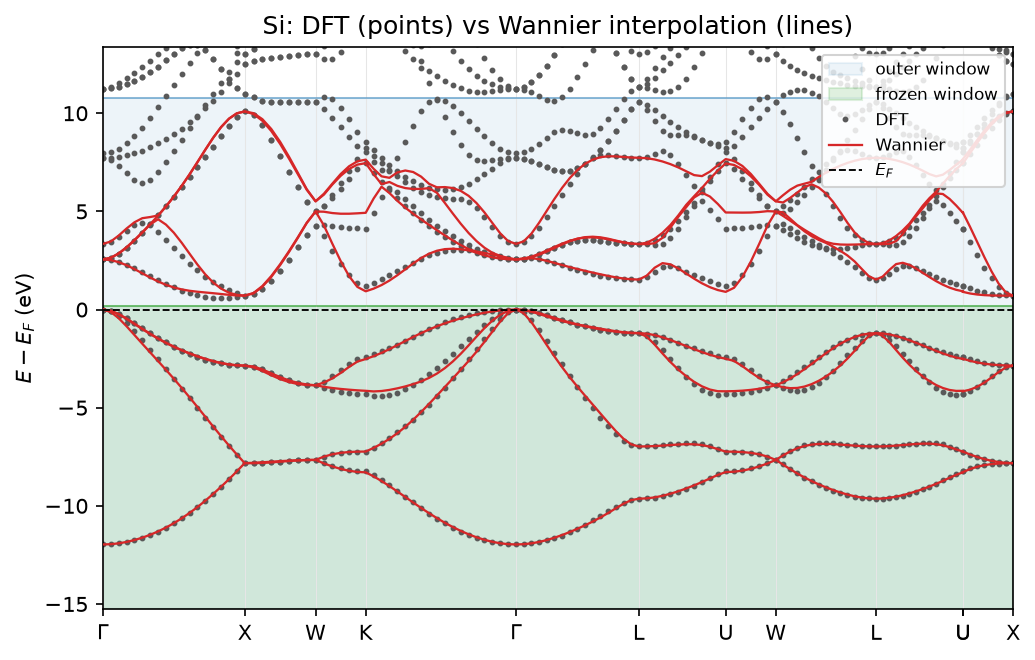

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e3, 17.0), frozen_window=(-1e3, 6.4), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(-1e3, 6.4), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** With PseudoDojo pseudos and waw's own optimiser + disentanglement — no `wannier90.x` — the 8-band $sp^3$ model reproduces Wannier90 tutorial 3's $\Omega_I$ and interpolates the silicon band structure across the valence and lower conduction bands.